In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Fitting function: $f(x) = \sum_{i=1}^M c_i \cos(ilx) + \sum_{i=1}^M c_i \sin(ilx)$

In [2]:
def read_xys(file_name):
  with open(file_name) as f:
    lines = f.readlines()
    x_ys = []
    for line in lines:
      x_y = line.split()
      x_ys.append((float(x_y[0]), float(x_y[1])))
    return np.array(x_ys)

In [3]:
class FuncList():
  def __init__(self, lst=[]):
    self._lst = lst
  
  def add(self, f):
    self._lst.append(f)
    return self
  
  def __call__(self, x):
    return np.array(list(map(lambda f: f(x), self._lst)))
  
  def __len__(self):
    return len(self._lst)
  
  def __repr__(self):
    return f'FuncList of {len(self._lst)}'

In [ ]:
def make_f_i(l, M):
  f_i = FuncList([lambda x: np.ones(len(x)) if isinstance(x, np.ndarray) else 1])
  def cos_f_i(i):
    return lambda x: np.cos(i * l * x)
  def sin_f_i(i):
    return lambda x: np.sin(i * l * x)
  for i in range(1, M//2+1):
    f_i.add(cos_f_i(i))\
       .add(sin_f_i(i))
  return f_i


def make_F(f_i, xys):
  N = np.shape(xys)[0]
  M = len(f_i)
  F = np.ones((N, M))
  for row, x in enumerate(xys[:, 0]):
      F[row][:] = f_i(x)
  return F

xys = read_xys('fit_points.txt')
# period (visually)
P = 1.5
l = 2 * np.pi / P
M = 7
f_i = make_f_i(l, M)
print(f_i)
F = make_F(f_i, xys)

FuncList of 7


In [8]:
A = np.transpose(F) @ F
b = np.transpose(F) @ xys[:, 1]
a = np.linalg.solve(A, b)
a

array([ 0.7435288 , -0.04116385, -0.47239672,  0.10156723, -0.23003604,
        0.03208436, -0.1314636 ])

Square mean norm: 0.028813706436762516


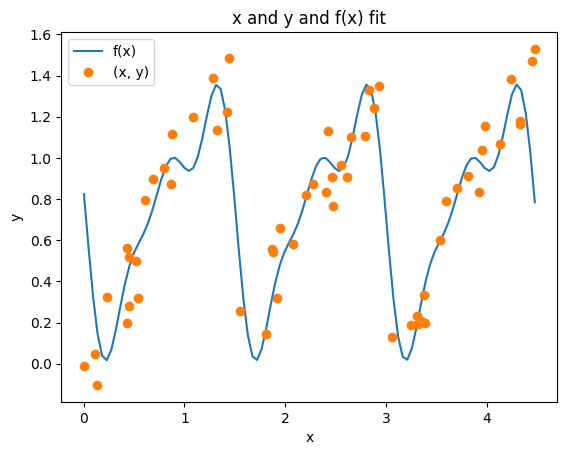

In [9]:
f = lambda x: a @ f_i(x)
xs = np.linspace(min(xys[:, 0]), max(xys[:, 0]), 100)
plt.plot(xs, f(xs), label='f(x)')
plt.plot(xys[:, 0], xys[:, 1], 'o', label='(x, y)')
plt.xlabel('x')
plt.ylabel('y')
plt.title('x and y and f(x) fit')
plt.legend()
error = np.sqrt(sum((xys[:, 1] - f(xys[:, 0]))**2)) / len(xys)
print(f'Square mean norm: {error}')

#### Right rectangular integration

$$
\int x e^{-x^2} \, dx
$$

$$
u = -x^2 \rightarrow du = -2xdx \rightarrow dx = -\frac{du}{2x}
$$

$$
\int x e^{-x^2} \, dx = -\frac{1}{2} \int e^u \, du
$$

$$
-\frac{1}{2} \int e^u \, du = -\frac{1}{2} e^u + C
$$

$$
\int x e^{-x^2} \, dx = -\frac{1}{2} e^{-x^2} + C
$$


In [4]:
def adaptive_right_rectangle(f, a, b, tolerance):
  memo_dict = {}
  def right_rectangle(f, x0, x1):
    # memoize f invocations
    nonlocal memo_dict
    val = 0
    if x1 in memo_dict: val = memo_dict[x1]
    else:
      val = f(x1)
      memo_dict[x0] = val
    return (x1 - x0) * val

  steps = 0
  def recursive_integrate(f, x0, x1, tolerance):
    nonlocal steps
    mid = (x0 + x1) / 2
    I1 = right_rectangle(f, x0, x1)
    I2 = right_rectangle(f, x0, mid) + right_rectangle(f, mid, x1)
    if abs(I2 - I1) < tolerance/3:
      steps += 1
      return I2
    else:
      return (recursive_integrate(f, x0, mid, tolerance/2) +
              recursive_integrate(f, mid, x1, tolerance/2))

  return (recursive_integrate(f, a, b, tolerance), steps)

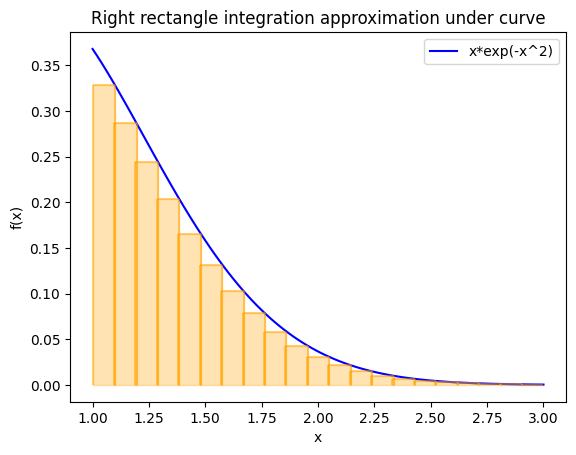

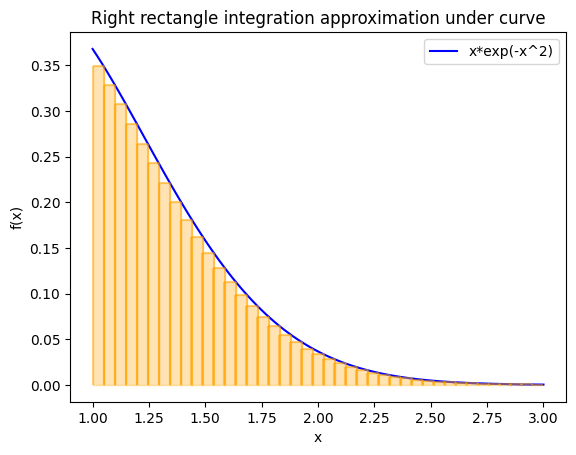

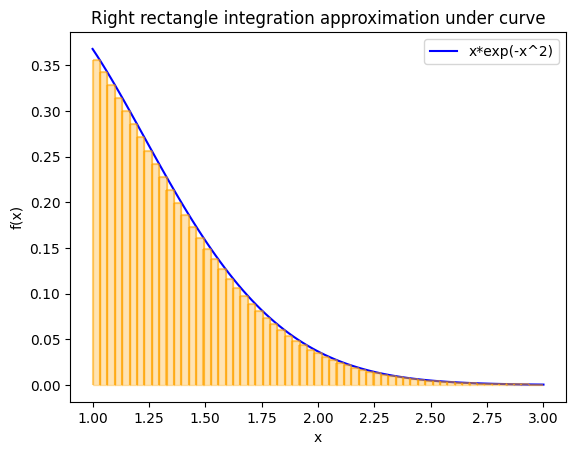

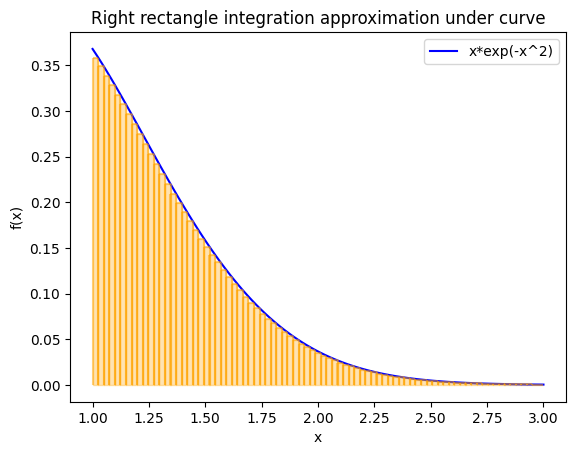

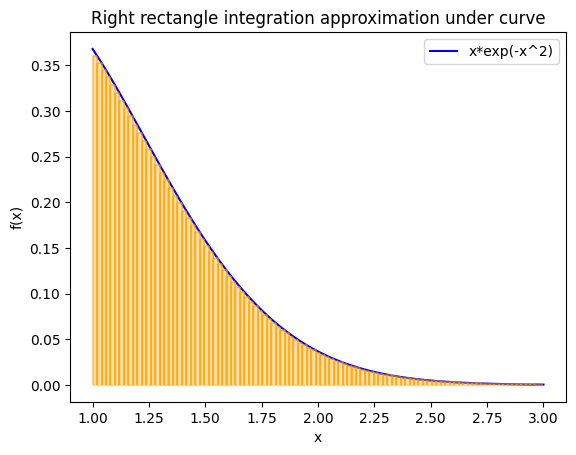

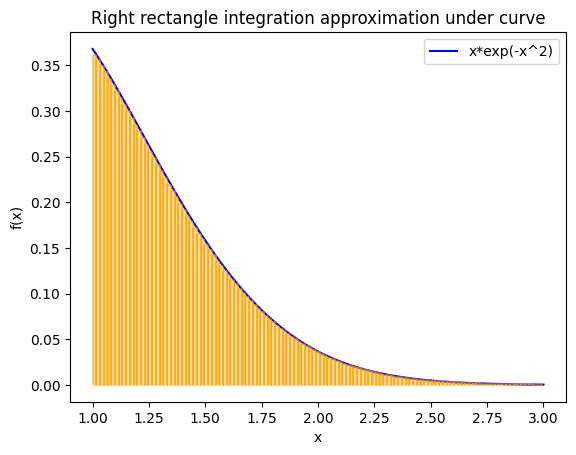

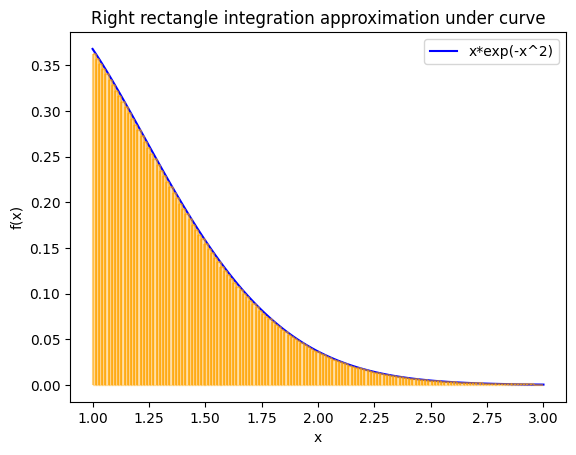

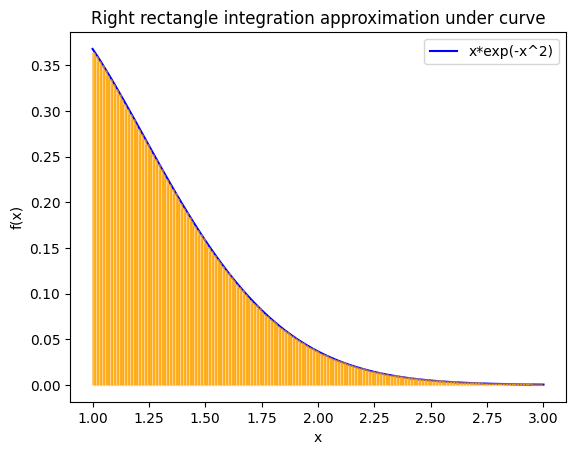

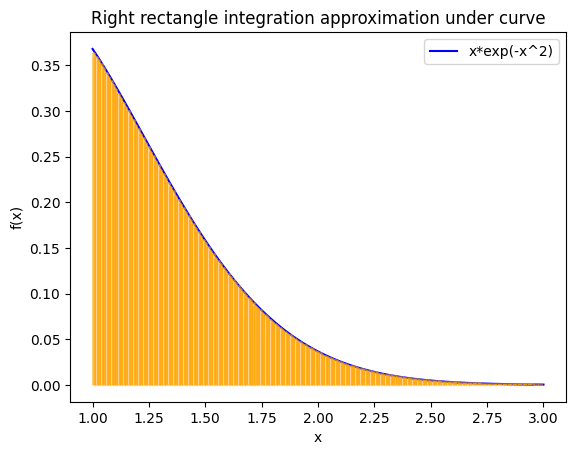

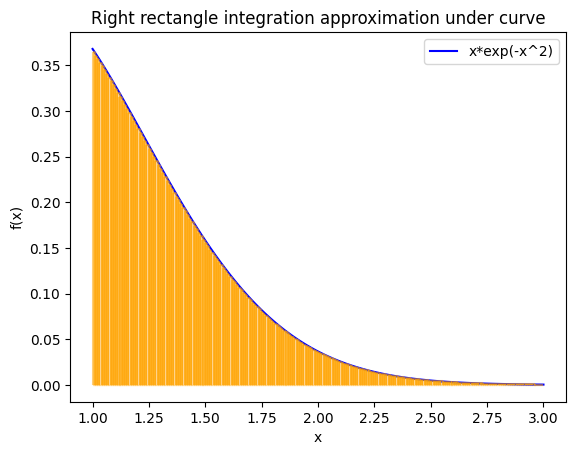

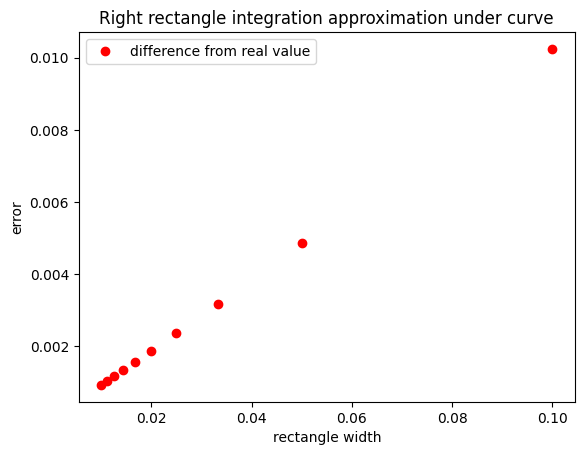

,rect.count,adapt.steps,rect.width,err.normal,err.adapt,err.bound
0,20.0,352.0,0.100000,0.010244,0.010481,0.044625
1,40.0,689.0,0.050000,0.004858,0.008454,0.022313
2,60.0,1255.0,0.033333,0.003180,0.007566,0.014875
3,80.0,1497.0,0.025000,0.002362,0.001881,0.011156
4,100.0,2281.0,0.020000,0.001879,0.001509,0.008925
5,120.0,2560.0,0.016667,0.001560,0.001304,0.007438
6,140.0,2792.0,0.014286,0.001334,0.001218,0.006375
7,160.0,2931.0,0.012500,0.001164,0.001156,0.005578
8,180.0,3834.0,0.011111,0.001033,0.001044,0.004958
9,200.0,4466.0,0.010000,0.000929,0.000970,0.004463


In [5]:
def plot_integration(right_values, hs, h):
  # Draw rectangles
  for x, y in zip(hs, right_values):
    x_prev = x - h
    # Left line
    plt.vlines(x_prev, ymin=0, ymax=y, color='orange', alpha=0.5)
    # Right line
    plt.vlines(x, ymin=0, ymax=y, color='orange', alpha=0.5)
    # Top line
    plt.hlines(y, xmin=x_prev, xmax=x, color='orange', alpha=0.5)
    plt.fill_betweenx([0, y], x_prev, x, color='orange', alpha=0.3)
  plt.xlabel('x')
  plt.ylabel('f(x)')
  plt.title('Right rectangle integration approximation under curve')
  plt.legend()
  plt.show()

ns = np.fromfunction(lambda i: 20*(i+1), (10, ), dtype=int)
f = lambda x: x * np.exp(-x**2)
f_ = lambda x: np.exp(-x**2) * (1 - 2*x*x)
F = lambda x: -0.5 * np.exp(-x**2)
a = 1
b = 3 
real_area = F(b) - F(a)
interval_length = b - a
xs = np.linspace(a, b, 100)
M = max(abs(f_(xs)))
M_scaled = M * (b - a) / 2
ys = f(xs)
results = pd.DataFrame({'rect.count' : [], 'adapt.steps' : [], 'rect.width' : [], 'err.normal' : [], 'err.adapt': [], 'err.bound' : []})
# with adaptive algorithm
for n in ns:
  h = interval_length / n
  hs = np.linspace(a+h, b, n+1)
  right_values = f(hs)
  plt.plot(xs, ys, label='x*exp(-x^2)', color='blue')
  plot_integration(right_values, hs, h)
  approx_area = sum(right_values) * h
  error = abs(real_area - approx_area)
  error_bound = M_scaled * h
  adaptive_area, adaptive_steps = adaptive_right_rectangle(f, a, b, error_bound)
  adaptive_area_error = abs(real_area - adaptive_area)
  results.loc[len(results)] = [n, adaptive_steps, h, error, adaptive_area_error, error_bound]

plt.plot(results['rect.width'], results['err.normal'], 'ro', label='difference from real value')
plt.xlabel('rectangle width')
plt.ylabel('error')
plt.legend()
plt.title('Right rectangle integration approximation under curve')
plt.show()
results